In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
train_path = "Training"
test_path = "Testing"

In [3]:
IMG_SIZE=200
BATCH_SIZE=32

In [4]:
train_datagen=ImageDataGenerator(rescale=1./255,rotation_range=20,zoom_range=0.2,shear_range=0.2,horizontal_flip=True)
test_datagen=ImageDataGenerator(rescale=1./255)

In [5]:
train_generator=train_datagen.flow_from_directory(train_path,target_size=(IMG_SIZE,IMG_SIZE),batch_size=BATCH_SIZE,class_mode="categorical")
test_generator=test_datagen.flow_from_directory(test_path,target_size=(IMG_SIZE,IMG_SIZE),batch_size=BATCH_SIZE,class_mode="categorical",shuffle=False)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [6]:
print(train_generator.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [8]:
model=Sequential()
model.add(Conv2D(32,(3,3),activation="relu",input_shape=(IMG_SIZE,IMG_SIZE,3)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64,(3,3),activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(128,(3,3),activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128,activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(64,activation="relu"))
model.add(Dropout(0.3))
model.add(Dense(4, activation='softmax'))

In [9]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)                    │ (None, 198, 198, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 99, 99, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 97, 97, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 48, 48, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 46, 46, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 23, 23, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 67712)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       8,667,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,769,028 (33.45 MB)

 Trainable params: 8,769,028 (33.45 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [11]:
early_stop=EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)

In [12]:
history=model.fit(train_generator,validation_data=test_generator,epochs=20,callbacks=[early_stop])

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 377s 2s/step - accuracy: 0.5484 - loss: 1.0217 - val_accuracy: 0.6544 - val_loss: 1.1621
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 372s 2s/step - accuracy: 0.7009 - loss: 0.7382 - val_accuracy: 0.6850 - val_loss: 0.8703
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 400s 2s/step - accuracy: 0.7402 - loss: 0.6424 - val_accuracy: 0.7212 - val_loss: 0.8192
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 380s 2s/step - accuracy: 0.7616 - loss: 0.5949 - val_accuracy: 0.7650 - val_loss: 0.7108
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 359s 2s/step - accuracy: 0.7873 - loss: 0.5356 - val_accuracy: 0.6925 - val_loss: 1.2329
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 354s 2s/step - accuracy: 0.8082 - loss: 0.5001 - val_accuracy: 0.7450 - val_loss: 0.9189
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 270s 2s/step - accuracy: 0.8186 - loss: 0.4748 - val_accuracy: 0.6456 - val_loss: 1.5562
Epoch 8/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 255s 1s/step - accuracy: 0.8155 - loss: 0.4792 - val_accu

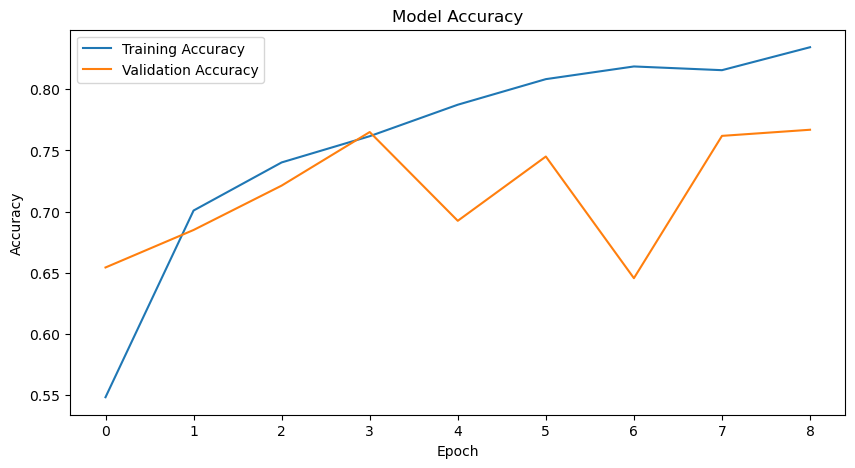

In [13]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

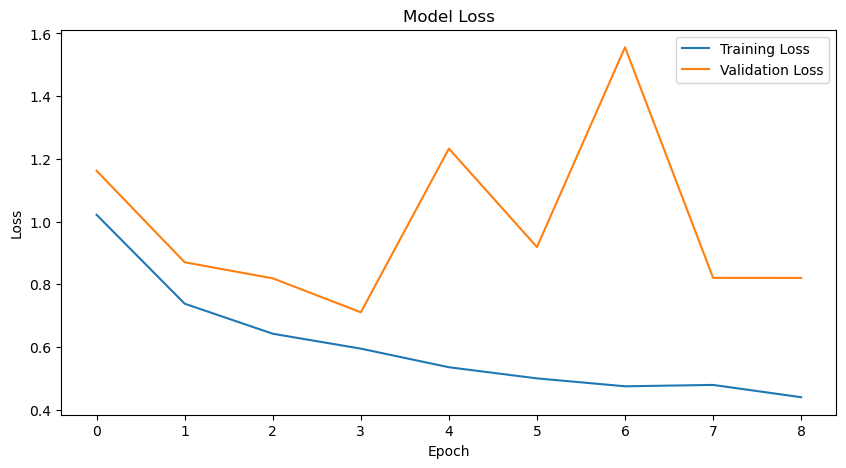

In [14]:
plt.figure(figsize=(10,5))
plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [15]:
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 258ms/step - accuracy: 0.7650 - loss: 0.7108
Test Loss: 0.7108
Test Accuracy: 76.50%


In [16]:
from tensorflow.keras.preprocessing import image
img_path = "Testing/notumor/Te-no_56.jpg"   # Replace with an actual image
img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img = image.img_to_array(img)
img = img / 255.0
img = np.expand_dims(img, axis=0)
prediction = model.predict(img)
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']
predicted_class = classes[np.argmax(prediction)]
print("Prediction:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step
Prediction: notumor


In [17]:
model.save("brain_tumor_model.keras")
print("Model saved successfully")

Model saved successfully
